In [ ]:
# Implementation for Data Cleaning
# Step 1: Import Libraries and Load Dataset

from google.colab import files
uploaded = files.upload() # upload the file

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv('Titanic-Dataset.csv') # Convert the file into pandas DataFrame
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Step 2: Check for Duplicate Rows

df.duplicated().sum()

np.int64(0)

In [ ]:
# Step 3: Identify Column Data Types

# Separate categorical and numerical columns.

categorical_columns =  [col for col in df.columns if df[col].dtype == 'object'] # .dtype tells you the data type of the values stored in a column
numerical_columns = [col for col in df.columns if df[col].dtype != 'object']     # object data type → text/strings (or mixed types) — pandas uses object as its label for text columns

print('categorical columns: ', categorical_columns)
print('numerical columns: ', numerical_columns)

# This separation matters because you handle them differently:

# Numerical columns → can compute mean/median, detect outliers, scale them
# Categorical columns → can compute mode, count unique values, check for typos



categorical columns:  ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
numerical columns:  ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [ ]:
# Step 4: Count Unique Values in the Categorical Columns

df[categorical_columns].nunique() #  Returns count of unique values per column.

,0
Name,891
Sex,2
Ticket,681
Cabin,147
Embarked,3


In [ ]:
# Step 5: Calculate Missing Values as Percentage

# Calculate % of missing values per column:
# (count of missing per column / total rows * 100 for percentage, rounded to 2 decimals)
round(df.isnull().sum() / df.shape[0] * 100, 2) # [0] accesses the rows from .shape → (rows, columns)

,0
PassengerId,0.00
Survived,0.00
Pclass,0.00
Name,0.00
Sex,0.00
Age,19.87
SibSp,0.00
Parch,0.00
Ticket,0.00
Fare,0.00


In [ ]:
# Step 6: Drop Irrelevant or Data-Heavy Missing Columns

# df.drop(columns=[]): Drops specified columns from the DataFrame.
# df.dropna(subset=[]): Removes rows where specified columns have missing values.
# fillna(): Fills missing values with specified value (e.g., mean).

df1 = df.drop(columns= ['Name', 'Ticket', 'Cabin'])
df1.dropna(subset=['Embarked'], inplace= True)
df1['Age'] = df1['Age'].fillna(df1['Age'].mean())



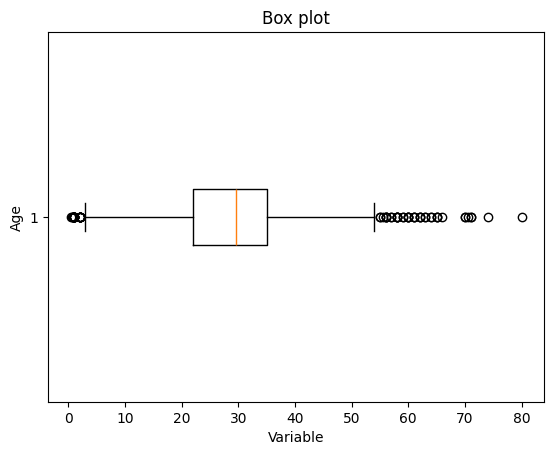

In [ ]:
# Step 7: Detect Outliers with Box Plot

# matplotlib.pyplot.boxplot(): Displays distribution of data, highlighting median, quartiles and outliers.
# plt.show(): Renders the plot.

import matplotlib.pyplot as plt

plt.boxplot(df1['Age'], vert= False)
plt.xlabel('Variable')
plt.ylabel('Age')
plt.title('Box plot')
plt.show()

In [ ]:
# Step 8: Calculate Outlier Boundaries and Remove Them

# Calculate mean and standard deviation (std)

mean = df['Age'].mean() # .mean() → the average, Add up all values, divide by how many there are.
std = df['Age'].std() # .std() → Standard deviation, measures how spread out the values are from the mean.

# Define bounds as mean ± 2 * std for outlier detection.

lower_bound = mean - 2*std  # anything below this = outlier (too low)
upper_bound = mean + 2*std  # anything above this = outlier (too high)

# Filter DataFrame rows within bounds using Boolean indexing.

df2 = df1[(df1['Age'] >= lower_bound) & (df1['Age'] <= upper_bound)]


In [ ]:
# Step 9: Impute Missing Data Again if Any
# fillna() applied again on filtered data to handle any remaining missing values.

df3 = df2.fillna(df2['Age'].mean())
df3.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [ ]:
# Step 10: Recalculate Outlier Bounds and Remove Outliers from the Updated Data

mean = df3['Age'].mean()
std = df3['Age'].std()

lower_bound = mean - 2*std
upper_bound = mean + 2*std

print("lower bound: ", lower_bound)
print("upper bound: ", upper_bound)

df4 = df3[(df3['Age'] >= lower_bound) & (df3['Age'] <= upper_bound)]



lower bound:  5.598990366524458
upper bound:  51.55060407552752


In [ ]:
# Step 11: Data validation and verification

# Data validation and verification involve ensuring that the data is accurate and consistent by comparing it with external sources or expert knowledge.

# For the machine learning prediction we separate independent and target features
# Here we will consider 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', and 'Embarked' as independent features.
# Survived as target variables because PassengerId will not affect the survival rate

X = df3[['Pclass','Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
y = df3['Survived']

In [ ]:
# Step 12: Data formatting
# Data formatting involves converting the data into a standard format or structure that can be easily processed by the algorithms or models used for analysis. Here we will discuss commonly used data formatting techniques i.e. Scaling and Normalization.

# 1. Min-Max Scaling: Scaling involves transforming the values of features to a specific range. Min-Max scaling rescales the values to a specified range, typically between 0 and 1. It preserves the original distribution and ensures that the minimum value maps to 0 and the maximum value maps to 1.

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

num_col = [col for col in X.columns if X[col].dtype != 'object']
x1 = X.copy()  # preserve the original X in case you need the unscaled version late
x1[num_col] = scaler.fit_transform(x1[num_col])
x1.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1.0,male,0.372057,0.125,0.0,0.014151,S
1,0.0,female,0.651143,0.125,0.0,0.139136,C
2,1.0,female,0.441828,0.000,0.0,0.015469,S
3,0.0,female,0.598814,0.125,0.0,0.103644,S
4,1.0,male,0.598814,0.000,0.0,0.015713,S


In [ ]:
# 2. Standardization (Z-score scaling): Standardization transforms the values to have a mean of 0 and a standard deviation of 1. It centers the data around the mean and scales it based on the standard deviation. Standardization makes the data more suitable for algorithms that assume a Gaussian distribution or require features to have zero mean and unit variance.

# Z = (X - μ) / σ

# Where,

# X = Data
# μ = Mean value of X
# σ = Standard deviation of X